In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report



In [2]:
# Load the passenger data
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Checking out the target
df.Survived.value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [12]:
df.duplicated().sum()

0

In [16]:
# Update sex column to numerical

df['Sex'] =df.Sex.apply(lambda x: 1 if x == 'female' else 0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# Fill the nan values in the age column

df.Age.fillna(df.Age.mean(), inplace=True)

In [ ]:
df.Cabin.value_counts() # Can be ignored/avoided

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [25]:
# Fill the embarked
df.Embarked.fillna(df.Embarked.mode()[0], inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [27]:
# Below 2 steps are defining one-hot/dummy encoding
# Create a first class column
# Create a second class column

df['FirstClass'] = df.Pclass.apply(lambda x: 1 if x == 1 else 0)
df['SecondClass'] = df.Pclass.apply(lambda x: 1 if x == 2 else 0)

In [29]:
# Select the desired features
new_df = df.loc[:, ['Survived', 'Sex', 'Age', 'FirstClass', 'SecondClass']]

In [ ]:
# Perform train, test, split

X = new_df[new_df.columns.difference(['Survived'])]
y = new_df.Survived

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3)

(623, 4)

In [37]:

# Scale the feature data so it has mean = 0 and standard deviation = 1

sc = StandardScaler()
train_X = sc.fit_transform(train_X) 
test_X = sc.transform(test_X) 

In [40]:
# Create and train the model

lr = LogisticRegression()
lr.fit(train_X, train_y)

LogisticRegression()

In [41]:
# Score the model on the train data
lr.score(train_X, train_y)

0.8170144462279294

In [43]:
print(classification_report(train_y, lr.predict(train_X)))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       398
           1       0.75      0.74      0.75       225

    accuracy                           0.82       623
   macro avg       0.80      0.80      0.80       623
weighted avg       0.82      0.82      0.82       623



In [42]:
# Score the model on the test data

lr.score(test_X, test_y)

0.7649253731343284

In [44]:
print(classification_report(test_y, lr.predict(test_X)))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       151
           1       0.77      0.66      0.71       117

    accuracy                           0.76       268
   macro avg       0.77      0.75      0.76       268
weighted avg       0.77      0.76      0.76       268



In [ ]:
# Analyze the coefficients

pd.DataFrame([X.columns, lr.coef_.flatten()], index=['Columns', 'coefficients']).T

,Columns,coefficients
0,Age,-0.450023
1,FirstClass,1.097718
2,SecondClass,0.430276
3,Sex,1.362013


In [72]:
# Sample passenger features
Jack = np.array([0.0,20.0,0.0,0.0])
Rose = np.array([1.0,17.0,1.0,0.0])

dummy_data = pd.DataFrame([Jack, Rose], columns=['Sex', 'Age', 'FirstClass', 'SecondClass'])
dummy_data = dummy_data[X.columns]
# Scale the sample passenger features
scaled_data = sc.transform(dummy_data)

In [74]:
# Make survival predictions!
lr.predict_proba(scaled_data)

array([[0.90844984, 0.09155016],
       [0.03741985, 0.96258015]])

In [75]:
# Appendix

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FirstClass,SecondClass
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0,0


In [ ]:
# Dropping insignificant columns

df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Pclass'], inplace=True)

In [77]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FirstClass,SecondClass
0,0,3,0,22.0,1,0,7.2500,S,0,0
1,1,1,1,38.0,1,0,71.2833,C,1,0
2,1,3,1,26.0,0,0,7.9250,S,0,0
3,1,1,1,35.0,1,0,53.1000,S,1,0
4,0,3,0,35.0,0,0,8.0500,S,0,0


In [79]:
df = pd.get_dummies(data=df, columns=['Embarked'], drop_first=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FirstClass,SecondClass,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,False,True
1,1,1,1,38.0,1,0,71.2833,1,0,False,False
2,1,3,1,26.0,0,0,7.9250,0,0,False,True
3,1,1,1,35.0,1,0,53.1000,1,0,False,True
4,0,3,0,35.0,0,0,8.0500,0,0,False,True


In [87]:
X = df[df.columns.difference(['Survived'])]
y = df.Survived

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3)

In [88]:
# Fitting the model on raw data
lr1 = LogisticRegression()
lr1.fit(train_X, train_y)

c:\Users\abhis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [89]:
lr1.score(train_X, train_y)

0.8009630818619583

In [90]:
lr1.score(test_X, test_y)

0.7947761194029851

In [91]:
# Analyze the coefficients

pd.DataFrame([X.columns, lr1.coef_.flatten()], index=['Columns', 'coefficients']).T

,Columns,coefficients
0,Age,-0.029611
1,Embarked_Q,0.115919
2,Embarked_S,-0.292397
3,Fare,0.000715
4,FirstClass,1.76405
5,Parch,-0.040988
6,SecondClass,0.823687
7,Sex,2.542636
8,SibSp,-0.291529


In [92]:
print(classification_report(train_y, lr1.predict(train_X)))
print(classification_report(test_y, lr1.predict(test_X)))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       391
           1       0.76      0.67      0.72       232

    accuracy                           0.80       623
   macro avg       0.79      0.77      0.78       623
weighted avg       0.80      0.80      0.80       623

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       158
           1       0.77      0.71      0.74       110

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.79       268
weighted avg       0.79      0.79      0.79       268



In [93]:
# Now, scaled the data

sc = StandardScaler()
train_X = sc.fit_transform(train_X) 
test_X = sc.transform(test_X) 

In [94]:
lr2 = LogisticRegression()
lr2.fit(train_X, train_y)

LogisticRegression()

In [95]:
print(classification_report(train_y, lr2.predict(train_X)))
print(classification_report(test_y, lr2.predict(test_X)))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       391
           1       0.75      0.67      0.71       232

    accuracy                           0.80       623
   macro avg       0.79      0.77      0.78       623
weighted avg       0.79      0.80      0.79       623

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       158
           1       0.77      0.70      0.73       110

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



<Axes: >

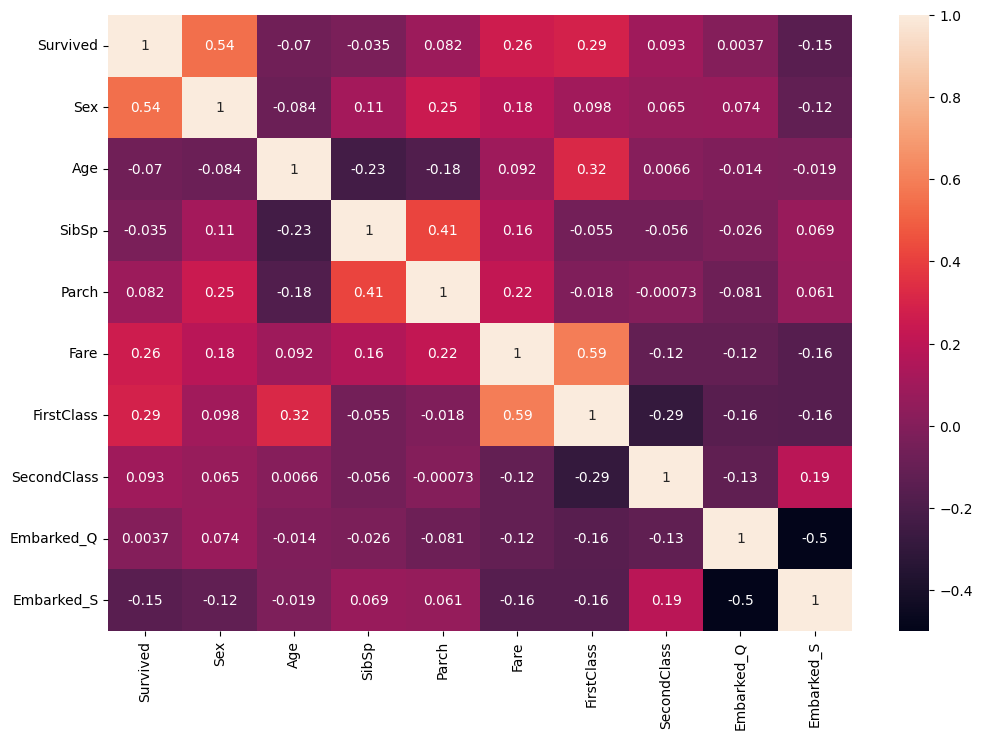

In [97]:
# Exploration - Handle the multicollinearity
import seaborn as sns
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), annot=True)